# Response of atmosphere to sea surface temperature bump using jax.jvp


## Import Packages

In [1]:
import os, sys
from pathlib import Path

# or `export PYTHONPATH=/path/to/jax-esm/root/directory`
sys.path.append( (Path(os.getcwd()) / ".." ).resolve())

In [2]:
import jcm
import jax_datetime as jdt

from jem.components import JCM, SlabOceanModel
from jem.mapping import BasicMapper
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

## Configurations

In [3]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
simulation_interval = jdt.to_timedelta(3, "day")
one_second = jdt.to_timedelta(1, "second")

## Create Components

In [4]:
# Creating components

atm_model = jcm.model.Model(
    start_date=start_datetime,
)

JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
    land_model_active=False,
)

components = dict(
    atm=atm_model,
    ocn=SlabOceanModel(
        start_datetime=start_datetime,
    ),
)

Notice: No mask_file given. Set fmask = 0.


## Creating Flux and Scalar Exchange between Components

In [5]:
# Creating regridders and mapping
identity = lambda x: x
mapper = BasicMapper(components=components)
mapper.add_mapping(
    source = ("atm", "derived.total_heat_flux"),
    target = ("ocn", "forcing.total_heat_flux"),
    regridder = identity,
)
mapper.add_mapping(
    source = ("ocn", "state.sea_surface_temperature"),
    target = ("atm", "forcing.sea_surface_temperature"),
    regridder = identity,
)

## Create Coupled Model

In [6]:
model = Coupler(
    components=components,
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Model info: 
/Model
├── ● component_info <dict>
│   ├── ● atm <dict>
│   │   └── ○ diffusion <str>: DiffusionFilter(vor_q_timescale=43200, vor_q_order=2, temp_timescale=86400, temp_order=2, div_timescale=7200, div_order=1)
│   └── ● ocn <dict>
│       └── ○ relaxation_time <float>: 5184000.0
└── ● mappers <dict>
  

## Run Coupled Model

In [7]:
import jax
import jax.numpy as jnp

initial_coupled_carry = model.initialize()

print("Create model trajectory function...")
trajectory_function = model.generate_trajectory_function(
    workflow=["mapper", "atm", "ocn"],
    iterations = int(simulation_interval / coupling_timestep),
)

@jax.jit
def f(sst):
    ocn_state = initial_coupled_carry["ocn"]["state"]
    initial_coupled_carry["ocn"]["state"] = ocn_state.copy({
        "sea_surface_temperature": sst,
    })
    final_carry, _ = trajectory_function(initial_coupled_carry)
    return final_carry["atm"]["derived"]["physics"].surface_flux.v0
    #return final_carry["ocn"]["state"]["sea_surface_temperature"]

sst_initial = initial_coupled_carry["ocn"]["state"]["sea_surface_temperature"]
shape2D = sst_initial.shape
tangent_sst_initial = jnp.zeros_like(sst_initial).at[shape2D[0]//2, shape2D[1]//2].set(1.0)

#v_final = f(sst_initial)
v_final, tangent_v_final = jax.jvp(f, (sst_initial,), (tangent_sst_initial,))


/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/nump

Boundary does not exist. Idealized initial SST will be used.
grid.bmask and SST_clim do share the same mask.
Notice: Climaology SST does not exist. Set relaxation time to inifinity.
Create model trajectory function...
Flattened workflow:  mapper, atm, ocn
Doing: ocn.state.sea_surface_temperature -> atm.forcing.sea_surface_temperature
Doing: atm.derived.total_heat_flux -> ocn.forcing.total_heat_flux


Simulation:   0%|          | 0/3 [00:00<?, ?it/s]

## Visualization

In [8]:
import matplotlib.pyplot as plt

### Atmosphere

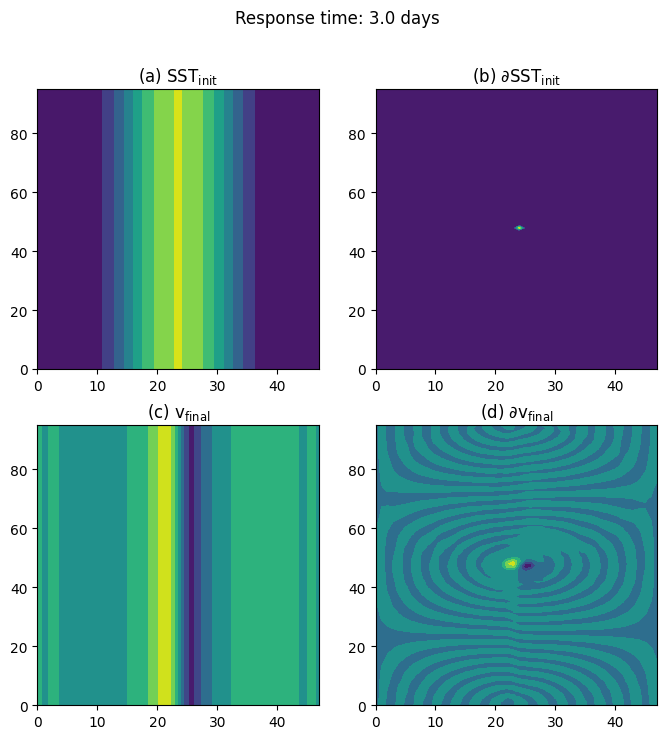

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(8,8))

ax[0, 0].contourf(sst_initial)
ax[0, 1].contourf(tangent_sst_initial)
ax[1, 0].contourf(v_final)
ax[1, 1].contourf(tangent_v_final)

ax[0, 0].set_title("(a) $\\mathrm{SST}_\\mathrm{init}$")
ax[0, 1].set_title("(b) $\\partial \\mathrm{SST}_\\mathrm{init}$")
ax[1, 0].set_title("(c) $\\mathrm{v}_\\mathrm{final}$")
ax[1, 1].set_title("(d) $\\partial \\mathrm{v}_\\mathrm{final}$")

fig.suptitle(f"Response time: {simulation_interval / jdt.to_timedelta(1, 'day'):.1f} days")

plt.show()